# Optional Supplement 01: Visualize a Tiny ViT Decision

This notebook uses **patch occlusion** to measure how masking each `4 × 4` image patch changes the trained model's predicted-class probability. The result is a 7 × 7 sensitivity heatmap.

> **Interpretability limit:** This heatmap is a diagnostic from one masking experiment. It is not a literal record of the model's reasoning, proof that a highlighted patch caused the decision, or forensic evidence.

## Step 1: Load the Saved Model

Run `03_tiny_vit_digits_demo.ipynb` first. It trains the model and creates `outputs/tiny_vit_mnist.pt`. This notebook reconstructs the same architecture and loads those learned weights; it does not train again.

In [1]:
import random
from pathlib import Path

try:
    import matplotlib.pyplot as plt
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import datasets, transforms
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'PyTorch, Torchvision, and Matplotlib are required. Run `pip install -r requirements.txt` from the repository root.'
    ) from exc

LAB_NAME = 'sub_01_vit_foundations'
lab_dir = Path.cwd().resolve()
if lab_dir.name != LAB_NAME:
    raise FileNotFoundError(f'Open this notebook from the {LAB_NAME} folder.')

checkpoint_path = lab_dir / 'outputs' / 'tiny_vit_mnist.pt'
if not checkpoint_path.exists():
    raise FileNotFoundError(
        'Missing outputs/tiny_vit_mnist.pt. Run 03_tiny_vit_digits_demo.ipynb from top to bottom first.'
    )

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Analysis device:', device)
print('Checkpoint:', checkpoint_path.relative_to(lab_dir))

Analysis device: cpu
Checkpoint: outputs/tiny_vit_mnist.pt


## Step 2: Recreate the Architecture

A checkpoint contains learned numbers, not an active model by itself. These class definitions match Notebook 03, allowing PyTorch to place every saved tensor into the correct layer.

In [2]:
class PatchEmbedding(nn.Module):
    """Convert image batches into sequences of learned patch embeddings."""
    def __init__(self, image_size=28, patch_size=4, channels=1, embedding_size=64):
        """Create the patch extractor and projection.

        Inputs: image size, patch size, channel count, and embedding length.
        Output: None; layers are stored in the new module.
        """
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError('image_size must be divisible by patch_size')
        self.number_of_patches = (image_size // patch_size) ** 2
        self.patch_dimension = channels * patch_size * patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.projection = nn.Linear(self.patch_dimension, embedding_size)

    def patch_vectors(self, images):
        """Return flattened patches for input images.

        Input: tensor shaped (batch, channels, height, width).
        Output: tensor shaped (batch, patches, patch_dimension).
        """
        return self.unfold(images).transpose(1, 2)

    def forward(self, images):
        """Project image patches into embeddings.

        Input: image tensor shaped (batch, channels, height, width).
        Output: tensor shaped (batch, patches, embedding_size).
        """
        return self.projection(self.patch_vectors(images))


class TinyVisionTransformer(nn.Module):
    """Small encoder-based Transformer for binary image classification."""
    def __init__(self, image_size=28, patch_size=4, embedding_size=64, heads=4, layers=2, classes=2):
        """Create the tiny ViT architecture.

        Inputs: image size, patch size, embedding length, attention heads, encoder layers, and class count.
        Output: None; model layers and learned placeholders are stored.
        """
        super().__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, 1, embedding_size)
        token_count = self.patch_embedding.number_of_patches + 1
        self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_size))
        self.position_embedding = nn.Parameter(torch.zeros(1, token_count, embedding_size))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_size, nhead=heads, dim_feedforward=embedding_size * 2,
            dropout=0.1, activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers, enable_nested_tensor=False)
        self.final_norm = nn.LayerNorm(embedding_size)
        self.classification_head = nn.Linear(embedding_size, classes)
        nn.init.normal_(self.class_token, std=0.02)
        nn.init.normal_(self.position_embedding, std=0.02)

    def tokens_before_encoder(self, images):
        """Create the CLS-plus-patch token sequence with position information.

        Input: image tensor shaped (batch, 1, 28, 28).
        Output: token tensor shaped (batch, 50, embedding_size).
        """
        patch_embeddings = self.patch_embedding(images)
        class_tokens = self.class_token.expand(images.shape[0], -1, -1)
        tokens = torch.cat((class_tokens, patch_embeddings), dim=1)
        return tokens + self.position_embedding

    def forward(self, images):
        """Classify input images.

        Input: image tensor shaped (batch, 1, 28, 28).
        Output: raw logits shaped (batch, 2), one score for each class.
        """
        tokens = self.tokens_before_encoder(images)
        encoded_tokens = self.encoder(tokens)
        class_representation = self.final_norm(encoded_tokens[:, 0])
        return self.classification_head(class_representation)

In [3]:
# weights_only=True restricts loading to tensors and simple checkpoint values.
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
required_keys = {
    'model_state_dict', 'model_config', 'class_names', 'normalization_mean',
    'normalization_std', 'seed', 'test_accuracy',
}
missing_keys = required_keys.difference(checkpoint)
if missing_keys:
    raise KeyError(f'Checkpoint is missing required values: {sorted(missing_keys)}')

model = TinyVisionTransformer(**checkpoint['model_config']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
CLASS_NAMES = list(checkpoint['class_names'])
SEED = int(checkpoint['seed'])
PATCH_SIZE = int(checkpoint['model_config']['patch_size'])
print('Loaded classes:', CLASS_NAMES)
print('Checkpoint test accuracy:', f'{checkpoint["test_accuracy"]:.1%}')

Loaded classes: ['3', '8']
Checkpoint test accuracy: 95.2%


## Step 3: Recreate the Same Held-Out Test Subset

The checkpoint supplies the seed and normalization settings. Using them here reproduces the same balanced set of 200 handwritten `3`s and 200 handwritten `8`s evaluated in Notebook 03.

In [4]:
ORIGINAL_TO_BINARY = {3: 0, 8: 1}
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(tuple(checkpoint['normalization_mean']), tuple(checkpoint['normalization_std'])),
])
full_test = datasets.MNIST(root=lab_dir / 'data', train=False, download=True, transform=transform)

def balanced_indices(targets, per_class, seed):
    """Select equal, reproducible groups of 3s and 8s.

    Inputs: MNIST labels, count per class, and integer random seed.
    Output: shuffled list of selected source-dataset positions.
    """
    rng = random.Random(seed)
    selected = []
    for original_label in ORIGINAL_TO_BINARY:
        candidates = [i for i, label in enumerate(targets) if int(label) == original_label]
        rng.shuffle(candidates)
        selected.extend(candidates[:per_class])
    rng.shuffle(selected)
    return selected

class BinaryDigitDataset(Dataset):
    """View selected MNIST 3s and 8s with binary labels."""
    def __init__(self, base_dataset, indices):
        """Store a source dataset and selected positions.

        Inputs: complete MNIST dataset and list of source positions.
        Output: None; both inputs are stored.
        """
        self.base_dataset = base_dataset
        self.indices = indices

    def __len__(self):
        """Return the integer number of selected images.

        Input: no explicit argument; stored indices are read.
        Output: integer dataset length.
        """
        return len(self.indices)

    def __getitem__(self, position):
        """Retrieve one normalized image and binary label.

        Input: integer position in this smaller dataset.
        Output: tuple of image tensor and label (0 for 3, 1 for 8).
        """
        image, original_label = self.base_dataset[self.indices[position]]
        return image, ORIGINAL_TO_BINARY[original_label]

test_indices = balanced_indices(full_test.targets, per_class=200, seed=SEED + 1)
test_dataset = BinaryDigitDataset(full_test, test_indices)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
print('Held-out images:', len(test_dataset))

Held-out images: 400


## Step 4: Choose Representative Predictions

We select one correct `3`, one correct `8`, and one model error. If this particular checkpoint has no error, the least-confident prediction is used instead. Raw logits are unrestricted scores; softmax converts them into two probabilities that sum to one.

In [5]:
all_images, all_labels, all_logits = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        all_images.append(images)
        all_labels.append(labels)
        all_logits.append(model(images.to(device)).cpu())
all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_logits = torch.cat(all_logits)
all_probabilities = torch.softmax(all_logits, dim=1)
all_confidences, all_predictions = all_probabilities.max(dim=1)

correct_three = torch.where((all_labels == 0) & (all_predictions == 0))[0][0].item()
correct_eight = torch.where((all_labels == 1) & (all_predictions == 1))[0][0].item()
errors = torch.where(all_predictions != all_labels)[0]
third_index = errors[0].item() if len(errors) else all_confidences.argmin().item()
third_name = 'model error' if len(errors) else 'least-confident prediction'
representatives = [
    ('correct 3', correct_three),
    ('correct 8', correct_eight),
    (third_name, third_index),
]

for name, index in representatives:
    logits = all_logits[index].tolist()
    probabilities = all_probabilities[index].tolist()
    actual = CLASS_NAMES[all_labels[index].item()]
    predicted = CLASS_NAMES[all_predictions[index].item()]
    print(f'{name:27s} actual={actual} predicted={predicted} logits={logits} probabilities={probabilities}')

correct 3                   actual=3 predicted=3 logits=[2.0372676849365234, -2.143523693084717] probabilities=[0.984943687915802, 0.015056248754262924]
correct 8                   actual=8 predicted=8 logits=[-2.7485432624816895, 2.9554708003997803] probabilities=[0.0033214930444955826, 0.9966784715652466]
model error                 actual=3 predicted=8 logits=[-0.3118583559989929, 0.8591387867927551] probabilities=[0.23667478561401367, 0.7633252143859863]


## Step 5: Measure Patch-Occlusion Sensitivity

For one image, create 49 copies. In each copy, replace a different 4×4 patch with normalized black (`-1.0`). Run all copies as one batch and compare the original predicted-class probability with each masked-image probability.

- **Positive score:** masking the patch lowered the original prediction, so that patch supported it under this test.
- **Negative score:** masking the patch increased the original prediction, so that patch suppressed it under this test.
- **Near zero:** masking that patch caused little probability change.

Masking creates an artificial image and can interact with other patches. The scores describe sensitivity to this intervention, not independent causal contributions.

In [6]:
@torch.no_grad()
def patch_occlusion_scores(model, image, patch_size, background_value, device):
    """Measure predicted-class sensitivity to masking every image patch.

    Inputs:
        model: Trained classifier in evaluation mode.
        image: One normalized image tensor shaped (1, 28, 28).
        patch_size: Width and height of each square patch.
        background_value: Normalized pixel value used to cover each patch.
        device: CPU, CUDA, or MPS device used for inference.

    Output:
        Dictionary containing baseline logits/probabilities, predicted class,
        7 × 7 signed influence scores, and probabilities for all 49 masked images.
    """
    if image.shape != (1, 28, 28):
        raise ValueError(f'Expected one image shaped (1, 28, 28), received {tuple(image.shape)}')
    grid_size = image.shape[-1] // patch_size
    patch_count = grid_size * grid_size
    baseline_logits = model(image.unsqueeze(0).to(device))
    baseline_probabilities = torch.softmax(baseline_logits, dim=1).squeeze(0)
    predicted_class = int(baseline_probabilities.argmax().item())
    baseline_probability = baseline_probabilities[predicted_class]

    occluded_images = image.unsqueeze(0).repeat(patch_count, 1, 1, 1)
    for patch_index in range(patch_count):
        row, column = divmod(patch_index, grid_size)
        row_start, column_start = row * patch_size, column * patch_size
        occluded_images[patch_index, :, row_start:row_start + patch_size, column_start:column_start + patch_size] = background_value

    occluded_logits = model(occluded_images.to(device))
    occluded_probabilities = torch.softmax(occluded_logits, dim=1)
    predicted_class_probabilities = occluded_probabilities[:, predicted_class]
    scores = baseline_probability - predicted_class_probabilities
    return {
        'baseline_logits': baseline_logits.squeeze(0).cpu(),
        'baseline_probabilities': baseline_probabilities.cpu(),
        'predicted_class': predicted_class,
        'scores': scores.reshape(grid_size, grid_size).cpu(),
        'occluded_probabilities': occluded_probabilities.cpu(),
        'occluded_images': occluded_images,
    }

occlusion_results = [
    patch_occlusion_scores(model, all_images[index], PATCH_SIZE, -1.0, device)
    for _, index in representatives
]
assert all(result['scores'].shape == (7, 7) for result in occlusion_results)
print('Created one baseline and 49 masked predictions for each representative image.')

Created one baseline and 49 masked predictions for each representative image.


## Step 6: Plot the Signed Influence Heatmaps

Red patches support the displayed prediction under this masking test; blue patches suppress it. Each row uses its own symmetric color scale because probability changes can differ greatly between examples.

/tmp/ipykernel_87218/2020354366.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


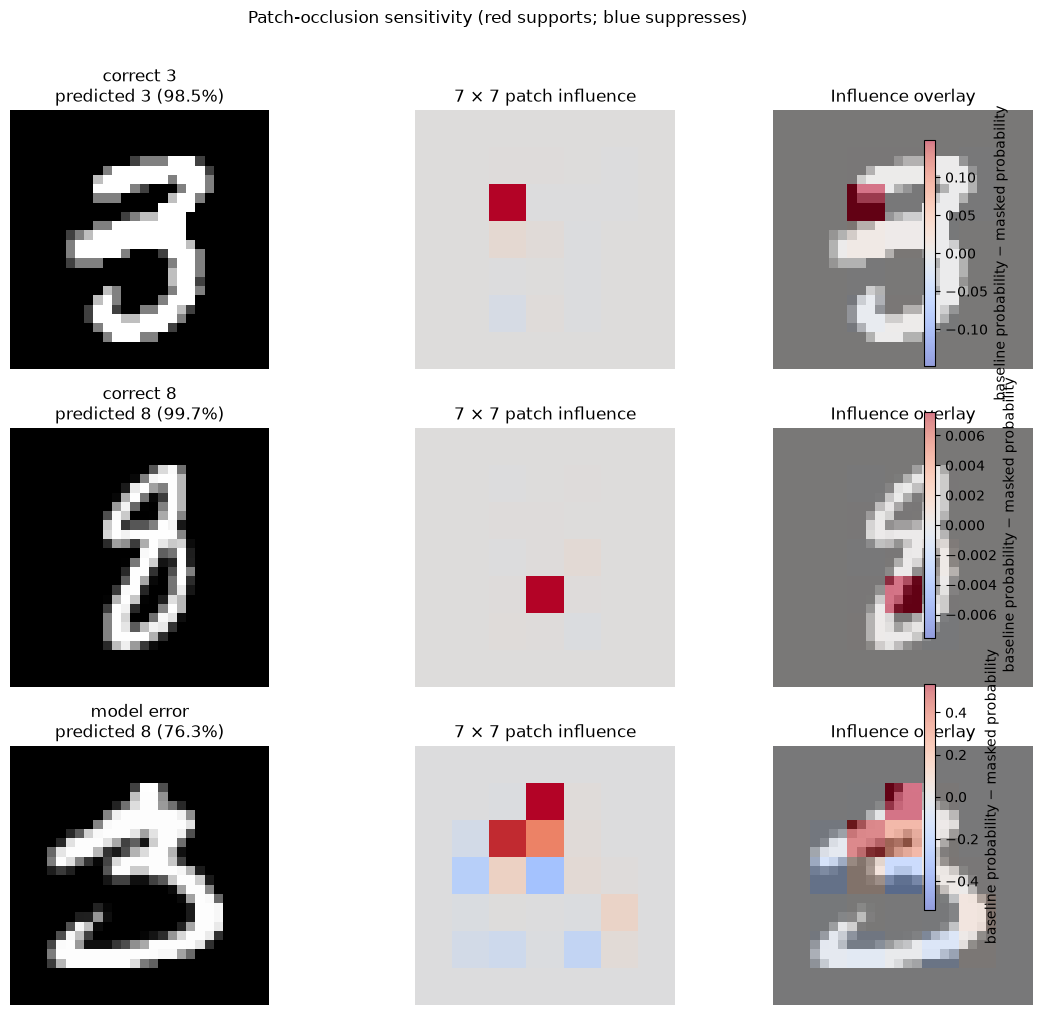

In [7]:
def image_for_display(image):
    """Undo MNIST normalization for plotting.

    Input: normalized image tensor shaped (1, 28, 28).
    Output: display tensor shaped (28, 28) with values in [0, 1].
    """
    return ((image * 0.5) + 0.5).clamp(0, 1).squeeze(0)

fig, axes = plt.subplots(len(representatives), 3, figsize=(11, 10))
for row, ((name, index), result) in enumerate(zip(representatives, occlusion_results)):
    display_image = image_for_display(all_images[index])
    scores = result['scores']
    pixel_heatmap = scores.repeat_interleave(PATCH_SIZE, 0).repeat_interleave(PATCH_SIZE, 1)
    magnitude = max(float(scores.abs().max()), 1e-6)
    predicted = CLASS_NAMES[result['predicted_class']]
    confidence = float(result['baseline_probabilities'][result['predicted_class']])

    axes[row, 0].imshow(display_image, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'{name}\npredicted {predicted} ({confidence:.1%})')
    axes[row, 1].imshow(scores, cmap='coolwarm', vmin=-magnitude, vmax=magnitude)
    axes[row, 1].set_title('7 × 7 patch influence')
    axes[row, 2].imshow(display_image, cmap='gray', vmin=0, vmax=1)
    overlay = axes[row, 2].imshow(pixel_heatmap, cmap='coolwarm', alpha=0.55, vmin=-magnitude, vmax=magnitude)
    axes[row, 2].set_title('Influence overlay')
    fig.colorbar(overlay, ax=axes[row, 1:3], fraction=0.025, pad=0.02, label='baseline probability − masked probability')
    for ax in axes[row]:
        ax.axis('off')
plt.suptitle('Patch-occlusion sensitivity (red supports; blue suppresses)', y=1.01)
plt.tight_layout()
plt.show()

### How to Read This Figure

Step 6 shows where the model's prediction is most sensitive to hiding individual `4 × 4` patches.

Each row represents one example:

- a correctly classified `3`;
- a correctly classified `8`;
- an incorrectly classified digit.

Each row has three panels:

1. **Original image**  
   Shows the handwritten digit, the model's prediction, and its confidence.
2. **7 × 7 patch-influence map**  
   Each square corresponds to one `4 × 4` patch in the original image.
   - Red: hiding this patch reduced confidence, so the patch supported the displayed prediction.
   - Blue: hiding this patch increased confidence, so the patch was suppressing the prediction.
   - Pale or white: hiding the patch caused little change.
3. **Influence overlay**  
   Places the same red-and-blue information over the original digit, making it easier to see which strokes occupy influential patches.

The color intensity represents the size of the probability change. A dark red patch had a larger supporting effect than a pale-red patch.

Each row has its own color scale. Therefore, the same shade of red in two different rows does not necessarily represent the same numerical change; use the color bar for that row.

For the incorrect example, strong red areas show patches that supported the model's wrong prediction. This helps explain why the model was sensitive to certain visual features, but it does not prove those patches independently caused the decision. The heatmap only shows what happened when each patch was replaced with black.

## Step 7: Inspect the Largest Probability Changes

Ranking by absolute change includes both strongly supporting and strongly suppressing patches. The row and column identify locations in the 7 × 7 patch grid.

In [8]:
for (name, _), result in zip(representatives, occlusion_results):
    predicted_class = result['predicted_class']
    baseline = float(result['baseline_probabilities'][predicted_class])
    flat_scores = result['scores'].flatten()
    influential = torch.topk(flat_scores.abs(), k=5).indices
    print(f'\n{name}: predicted {CLASS_NAMES[predicted_class]}, baseline probability={baseline:.3f}')
    print('patch   masked probability   signed change')
    for patch_index in influential:
        patch_index = int(patch_index)
        row, column = divmod(patch_index, 7)
        masked_probability = float(result['occluded_probabilities'][patch_index, predicted_class])
        signed_change = float(flat_scores[patch_index])
        print(f'({row}, {column})        {masked_probability:.3f}             {signed_change:+.3f}')


correct 3: predicted 3, baseline probability=0.985
patch   masked probability   signed change
(2, 2)        0.836             +0.149
(3, 2)        0.976             +0.009
(5, 2)        0.993             -0.008
(3, 3)        0.980             +0.005
(5, 3)        0.982             +0.003

correct 8: predicted 8, baseline probability=0.997
patch   masked probability   signed change
(4, 3)        0.989             +0.008
(3, 4)        0.996             +0.000
(5, 4)        0.997             -0.000
(5, 2)        0.997             +0.000
(2, 3)        0.997             +0.000

model error: predicted 8, baseline probability=0.763
patch   masked probability   signed change
(1, 3)        0.226             +0.537
(2, 2)        0.268             +0.496
(2, 3)        0.440             +0.323
(3, 3)        0.960             -0.197
(3, 1)        0.898             -0.135


## Step 8: Mask the Strongest Supporting Patch

For each example, mask the patch with the largest positive score and compare both class probabilities before and after masking. A confidence decrease or class change is evidence of sensitivity to that intervention—not proof that the patch independently caused the original decision.

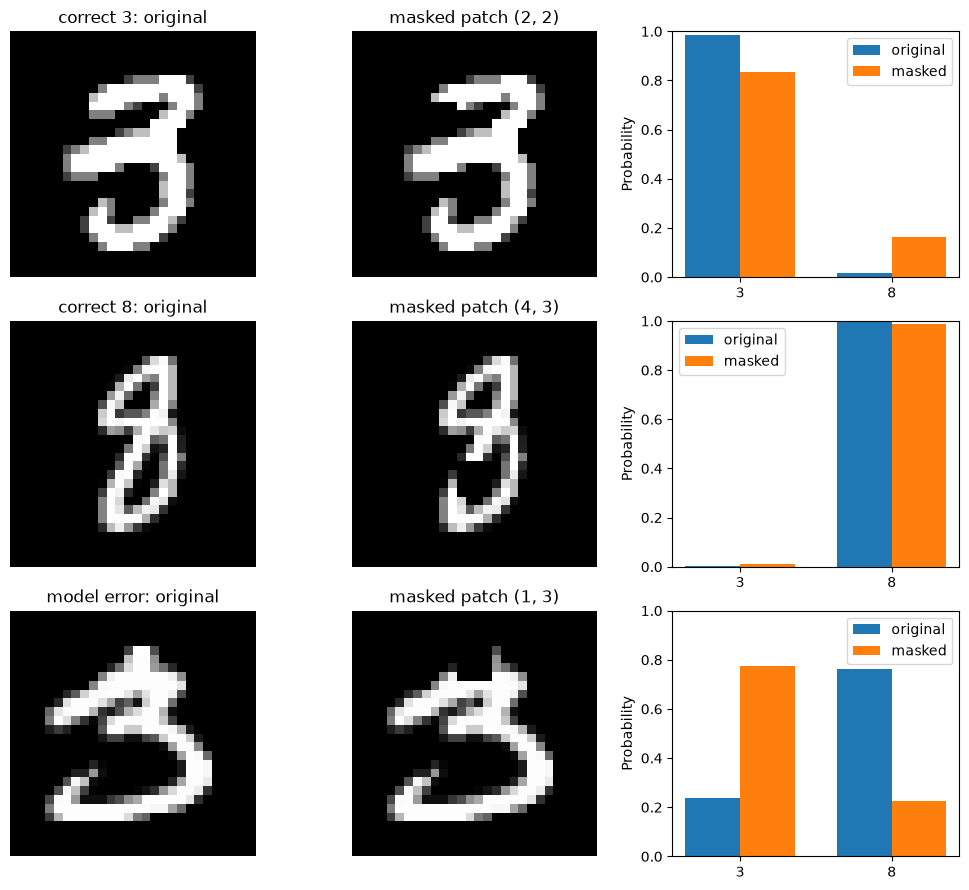

In [9]:
fig, axes = plt.subplots(len(representatives), 3, figsize=(10, 9))
x = torch.arange(2).numpy()
for row, (((name, index), result)) in enumerate(zip(representatives, occlusion_results)):
    strongest_patch = int(result['scores'].flatten().argmax())
    masked_image = result['occluded_images'][strongest_patch]
    before = result['baseline_probabilities'].numpy()
    after = result['occluded_probabilities'][strongest_patch].numpy()
    patch_row, patch_column = divmod(strongest_patch, 7)

    axes[row, 0].imshow(image_for_display(all_images[index]), cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'{name}: original')
    axes[row, 1].imshow(image_for_display(masked_image), cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f'masked patch ({patch_row}, {patch_column})')
    axes[row, 2].bar(x - 0.18, before, width=0.36, label='original')
    axes[row, 2].bar(x + 0.18, after, width=0.36, label='masked')
    axes[row, 2].set_xticks(x, CLASS_NAMES)
    axes[row, 2].set_ylim(0, 1)
    axes[row, 2].set_ylabel('Probability')
    axes[row, 2].legend()
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()

## Interpretation and Limits

Patch occlusion answers a narrow question: *How did the predicted-class probability change when this model saw an artificial black square at this location?* It does not reveal a hidden chain of thought. Adjacent patches can carry overlapping information, several patches can interact, and the black mask itself may be unlike normal MNIST images. Different baselines, patch sizes, or transformations can produce different heatmaps.

In forensic work, such a visualization can help an examiner inspect model sensitivity, but it cannot authenticate an image, establish provenance, validate a classifier, or replace examination of the original evidence and procedure.

## Reflection

1. Which patches most strongly support the correct `3` and correct `8` predictions?
2. Does the model error emphasize a visually plausible part of the digit?
3. Why can two neighboring patches both appear important?
4. How might replacing patches with gray instead of black change the heatmap?
5. Did masking one patch change only confidence, or did it change the predicted class?
6. Why is an occlusion heatmap a sensitivity diagnostic rather than proof of reasoning?
7. What additional validation would be required before using a visual classifier in a forensic workflow?